# Calculation of a VCD Spectrum

This tutorial demonstrates the calculation of a vibrational circular dichroism (VCD) spectrum using the ORCA python interface (OPI).

VCD measures the difference in absorbance of left- and right-circularly polarized infrared light. It is the vibrational analogue of ECD and a powerful probe of absolute configuration: the two enantiomers of a chiral molecule have *identical* IR spectra but VCD spectra of opposite sign. A calculation can therefore assign the configuration of a sample by matching the sign pattern.

We use **(_S_)-methyloxirane** (propylene oxide) as our example — with ten atoms it is one of the smallest genuinely chiral molecules and the standard benchmark for VCD.

In this notebook we will:
1.  Install and import the required Python dependencies
2.  Define a working directory
3.  Set up an input structure for our calculation
4.  Optimize the geometry and calculate the Hessian together with the VCD intensities
5.  Read the rotational strengths and the IR intensities
6.  Convolute both to spectra and plot them

## Step 1: Installing 3rd-party Dependencies

In [ ]:
import sys
!{sys.executable} -m pip install --upgrade numpy py3Dmol matplotlib

## Step 2: Import Dependencies

We start by importing the modules needed for:
- Interfacing with ORCA input/output
- Numerical calculations and data handling
- Plotting results

> **Note:** We additionally import modules for visualization/plotting like `py3Dmol`. For this, it might be necessary to install `py3Dmol` into your OPI `venv` (e.g., by activating the `.venv` and using `uv pip install py3Dmol`).

In [1]:
# > Import pathlib for directory handling
from pathlib import Path
import shutil

# > Import numpy for data handling and numerical operations
import numpy as np
# > Import libraries for visualization
import matplotlib.pyplot as plt
import py3Dmol

# > OPI imports for performing ORCA calculations and reading output
from opi.core import Calculator
from opi.input.simple_keywords import BasisSet, Dft, DispersionCorrection, SolvationModel, Solvent, Task
from opi.input.structures.structure import Structure
from opi.input.blocks.block_freq import BlockFreq
from opi.output.core import Output

## Step 3: Define Working Directory

All actual calculations will be performed in a subfolder **RUN**.

In [2]:
# > Calculation is performed in `RUN`
working_dir = Path("RUN")
# > The `working_dir`is automatically (re-)created
shutil.rmtree(working_dir, ignore_errors=True)
working_dir.mkdir()

## Step 4: Setup an Input Structure

We use **(_S_)-methyloxirane** as our example molecule. The 3D structure in Cartesian coordinates is defined in XYZ format and visualized.

> **Note:** For a chiral molecule the handedness of the input coordinates *is* the result. Feeding in the (_R_) structure by mistake produces a spectrum of exactly the opposite sign, without any warning, so it is worth verifying the configuration of the input geometry before interpreting the output.

In [3]:
# > Define the molecule's Cartesian coordinates in Angstroem as python string
xyz_data = """\
10

C           -1.23213400000000        0.11537900000000       -0.07276200000000
C            0.10422600000000       -0.53579500000000       -0.06401600000000
C            1.36674900000000        0.27174000000000        0.06939100000000
O            0.80280200000000       -0.44069500000000        1.18178600000000
H           -1.98211400000000       -0.55726600000000        0.35460100000000
H           -1.24050000000000        1.04572100000000        0.50461500000000
H           -1.52916700000000        0.34921000000000       -1.09962800000000
H            0.13124700000000       -1.47801900000000       -0.59375200000000
H            2.27746200000000       -0.12253200000000       -0.36340600000000
H            1.30142900000000        1.35225700000000        0.08317000000000\n
"""

# > Visualize the molecular structure using py3Dmol
view = py3Dmol.view(width=500, height=500)
view.addModel(xyz_data, "xyz")
view.setStyle({'stick': {'radius': 0.1}, 'sphere': {'scale': 0.2}})
view.setBackgroundColor('white')
view.zoomTo()
view.show()

# > Save the XYZ structure to a file
xyz_file = working_dir / "struc.xyz"
with open(xyz_file, "w") as f:
    f.write(xyz_data)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Step 5: Geometry Optimization and VCD Calculation

VCD intensities are requested with `dovcd` in the `%freq` block. Two constraints come with it:

- The Hessian must be **analytic** — VCD cannot be calculated with `NUMFREQ`.
- The Hessian has to be evaluated at a geometry optimized **at the same level of theory**, otherwise the residual gradient contaminates the normal modes.

We satisfy the second point by combining `Task.OPT` and `Task.FREQ` in a single job, so the optimization and the Hessian necessarily use the same method: `B3LYP-D4/def2-TZVP` with CPCM chloroform, matching the usual experimental conditions.

In [4]:
# > Create a Calculator object for ORCA input generation and execution
calc = Calculator(basename="vcd", working_dir=working_dir)

# > Load the molecular structure from the XYZ file
calc.structure = Structure.from_xyz(xyz_file)
calc.structure.charge = 0
calc.structure.multiplicity = 1

# > Add calculation keywords
calc.input.add_simple_keywords(
    Dft.B3LYP, # > B3LYP functional
    BasisSet.DEF2_TZVP, # > def2-TZVP basis set
    DispersionCorrection.D4, # > Use D4 model
    SolvationModel.CPCM(Solvent.CHLOROFORM), # > Implicit solvation
    Task.OPT, # > Optimize the geometry ...
    Task.FREQ, # > ... and calculate the analytic Hessian at that geometry
)

calc.input.add_blocks(
    BlockFreq(dovcd=True) # > Also calculate the VCD rotational strengths
)

# > Write the ORCA input file
calc.write_input()
# > Run the ORCA calculation
print("Running optimization and VCD calculation ...", end="")
calc.run()
print("   Done")

output = calc.get_output()
if not output.terminated_normally():
    raise RuntimeError(f"ORCA did not terminate normally, see output file: {output.get_outfile()}")

Running optimization and VCD calculation ...

   Done


## Step 6: Read the Rotational Strengths and IR Intensities

`Output.get_vcd()` returns the VCD rotational strengths and `Output.get_ir()` the IR intensities, both keyed by mode number. Unlike most OPI getters these read the plain-text output file rather than a JSON file, because ORCA does not write the spectra to JSON — so no `output.parse()` is needed here.

The decisive difference between the two is the sign: an IR intensity is a squared quantity and therefore always positive, while a rotational strength is a scalar product of the electric and magnetic transition dipole moments and can have either sign. That sign is what carries the stereochemical information.

In [5]:
vcd = output.get_vcd()
ir = output.get_ir()

print(f"{'mode':>5} {'freq / cm^-1':>13} {'IR / km/mol':>12} {'VCD / 1e-44 esu^2 cm^2':>24}")
for mode, vcd_mode in vcd.items():
    print(f"{mode:>5} {vcd_mode.wavenumber:>13.1f} {ir[mode].intensity:>12.2f} {vcd_mode.intensity:>24.2f}")

# > The band that dominates the VCD spectrum need not be the strongest IR band
strongest_vcd = max(vcd.values(), key=lambda m: abs(m.intensity))
strongest_ir = max(ir.values(), key=lambda m: m.intensity)
print(f"\nstrongest VCD band: mode {strongest_vcd.mode} at {strongest_vcd.wavenumber:.1f} cm^-1")
print(f"strongest IR  band: mode {strongest_ir.mode} at {strongest_ir.wavenumber:.1f} cm^-1")

 mode  freq / cm^-1  IR / km/mol   VCD / 1e-44 esu^2 cm^2
    6         211.4         0.68                    -4.39
    7         368.3         6.29                    14.52
    8         412.2         6.42                     6.13
    9         759.6        13.41                   -18.43
   10         833.0        77.80                    -4.33
   11         906.4         4.21                   -28.61
   12         965.0        24.11                    46.23
   13        1040.9        16.33                    -7.45
   14        1124.0         9.97                     9.31
   15        1153.8         4.52                    -3.84
   16        1165.7         5.21                    13.89
   17        1188.5         1.28                     0.93
   18        1291.3         8.74                     7.54
   19        1400.7         4.51                    -2.15
   20        1433.4        29.77                   -17.12
   21        1470.1         9.28                    -2.34
   22        1

## Step 7: Broadening and Plotting

As for any calculated spectrum of vertical transitions, the discrete lines are convoluted with a line shape — here a Gaussian of half-width $\gamma$ at $1/e$, which corresponds to a FWHM of $2\gamma\sqrt{\ln 2} \approx 1.67\,\gamma$.

For VCD the rotational strengths $R$ convert to the differential molar absorptivity via

$$ \Delta\epsilon(\tilde\nu) = \frac{1}{2.296 \cdot 10^{-39}} \sum_i \tilde\nu_i\, R_i\, g(\tilde\nu - \tilde\nu_i) $$

with $R$ in esu² cm², $\tilde\nu$ in cm⁻¹ and $g$ a normalized Gaussian, which gives $\Delta\epsilon$ in M⁻¹ cm⁻¹. The IR panel is plotted from the km/mol intensities in arbitrary units, since only the band pattern matters for the comparison.

The (_R_) enantiomer is added to the VCD panel as well. It is *not* a second calculation: mirroring a molecule leaves every frequency and IR intensity untouched and inverts every rotational strength, so its spectrum is exactly the negative of the one we computed.

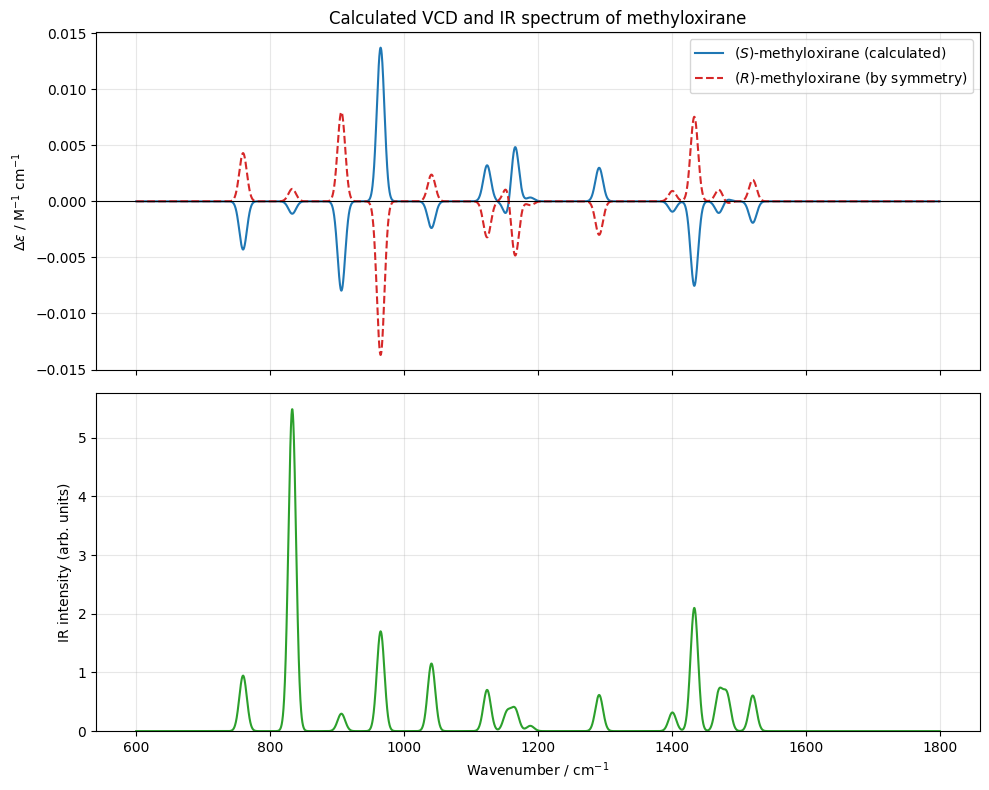

In [6]:
# > Gaussian half-width at 1/e in cm**-1
gamma = 8.0
# > Prefactor relating rotational strengths in esu**2 cm**2 to delta epsilon in M**-1 cm**-1
VCD_PREFACTOR = 1.0 / 2.296e-39
# > ORCA reports the rotational strengths in units of 1e-44 esu**2 cm**2
VCD_UNIT = 1.0e-44


def broaden(grid: np.ndarray, centres: np.ndarray, weights: np.ndarray) -> np.ndarray:
    """Convolute lines at `centres` with normalized Gaussians of half-width `gamma` at 1/e."""
    gaussians = np.exp(-(((grid[:, None] - centres[None, :]) / gamma) ** 2)) / (gamma * np.sqrt(np.pi))
    return gaussians @ weights


wavenumbers = np.array([mode.wavenumber for mode in vcd.values()])
rotational_strengths = np.array([mode.intensity for mode in vcd.values()])
ir_intensities = np.array([ir[mode].intensity for mode in vcd])

# > Restrict the plot to the fingerprint region, where VCD is usually measured
grid = np.linspace(600.0, 1800.0, 4000)

# > delta epsilon carries an additional factor of the wavenumber
delta_epsilon = VCD_PREFACTOR * broaden(grid, wavenumbers, rotational_strengths * VCD_UNIT * wavenumbers)
ir_spectrum = broaden(grid, wavenumbers, ir_intensities)

fig, (ax_vcd, ax_ir) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# > VCD spectrum of both enantiomers
ax_vcd.plot(grid, delta_epsilon, color="tab:blue", label="($S$)-methyloxirane (calculated)")
ax_vcd.plot(grid, -delta_epsilon, color="tab:red", ls="--", label="($R$)-methyloxirane (by symmetry)")
ax_vcd.axhline(0.0, color="black", lw=0.8)
ax_vcd.set_ylabel(r"$\Delta\epsilon$ / M$^{-1}$ cm$^{-1}$")
ax_vcd.set_title("Calculated VCD and IR spectrum of methyloxirane")
ax_vcd.legend()
ax_vcd.grid(True, alpha=0.3)

# > IR spectrum, identical for both enantiomers
ax_ir.plot(grid, ir_spectrum, color="tab:green")
ax_ir.set_ylim(bottom=0.0)
ax_ir.set_xlabel(r"Wavenumber / cm$^{-1}$")
ax_ir.set_ylabel("IR intensity (arb. units)")
ax_ir.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Summary

In this notebook we demonstrated how the ORCA Python interface can be employed to calculate a VCD spectrum. `BlockFreq(dovcd=True)` requests the rotational strengths alongside the analytic Hessian, and `Output.get_vcd()` and `Output.get_ir()` make both spectra directly available. The resulting VCD spectrum is signed and inverts with the configuration, while the IR spectrum does not.

A few points to keep in mind when going beyond this example:
- Methyloxirane is rigid. For a flexible molecule a single conformer is not enough: VCD bands of different conformers often have opposite signs and partly cancel, so a Boltzmann-weighted average over a conformer ensemble is required. ORCA's GOAT algorithm can generate that ensemble.
- Calculated harmonic frequencies are systematically too high. Scaling them (via `scalfreq` in `BlockFreq`) improves the match to experiment, though the sign pattern — the part that determines the configuration — is unaffected.
- The absolute configuration follows from the *pattern* of signs across several bands, not from a single band. A convincing assignment compares the whole fingerprint region.
- The related ECD spectrum of electronic transitions is reported by ORCA next to the UV/Vis absorption spectrum and is accessible through the property JSON output.